In [1]:
"""
Notebook 08: Large-Scale Evaluation & Timing Benchmarks
========================================================
Convert to notebook with: jupytext --to notebook notebooks/08_evaluation.py

Covers:
- Phase 11-12: Evaluation across 100+ frames, per-weather breakdown
- Phase 13: Timing benchmarks, FPS measurement
"""

'\nNotebook 08: Large-Scale Evaluation & Timing Benchmarks\n========================================================\nConvert to notebook with: jupytext --to notebook notebooks/08_evaluation.py\n\nCovers:\n- Phase 11-12: Evaluation across 100+ frames, per-weather breakdown\n- Phase 13: Timing benchmarks, FPS measurement\n'

# Notebook 08: Large-Scale Evaluation & Timing Benchmarks

**Course:** Digital Image Processing
**Project:** Automatic Parking Occupancy Estimation

---

## Objectives
1. Run the tuned pipeline on a large, diverse set of frames
2. Compute overall accuracy, precision, recall, F1
3. Generate per-weather confusion matrices
4. Identify consistently misclassified slots (error analysis)
5. Compare single-feature vs multi-feature cascade
6. Benchmark per-stage timing and compute FPS


## 1. Setup


In [2]:
import sys, os

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.path.abspath('.'))

import cv2
import numpy as np
import matplotlib
%matplotlib inline
try:
    get_ipython()
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd
import time

from src.utils import load_config
from src.io_utils import list_frames, parse_pklot_xml
from src.geometry import load_homography, warp_perspective
from src.roi import load_slots_json, extract_slot_image, create_eroded_core_mask
from src.preprocessing import preprocess_pipeline
from src.segmentation import otsu_threshold, adaptive_threshold, fuse_channels
from src.morphology import clean_binary_mask
from src.features import extract_all_features
from src.decide import classify_slot, load_thresholds
from src.evaluate import (compute_metrics, plot_confusion_matrix,
                           format_metrics_report, Timer)
from src.stats import compute_statistics, format_report
from src.visualize import annotate_parking_image, create_legend
from src.visualize import show_and_save_fig

config = load_config('config/config.yaml')
hdata = load_homography('config/homography.npz')
H, output_size = hdata['H'], hdata['output_size']
bev_slots = load_slots_json('config/slots.json')
thresholds, weights = load_thresholds('config/thresholds.yaml')

print(f"Loaded {len(bev_slots)} slots, thresholds ready")

Loaded 100 slots, thresholds ready


## 2. Build Evaluation Set

We select **~120 frames** evenly distributed across weather conditions,
ensuring we cover different times of day and dates.


In [3]:
DATA_ROOT = 'data/raw/PKLot'
LOT_PATH = os.path.join(DATA_ROOT, 'parking2')
all_frames = list_frames(LOT_PATH)

eval_frames = []
for weather in ['sunny', 'cloudy', 'rainy']:
    w_frames = [f for f in all_frames if f['weather'] == weather]
    # Take every Nth frame to get ~40 per weather
    step = max(1, len(w_frames) // 40)
    eval_frames.extend(w_frames[::step][:40])

print(f"Evaluation set: {len(eval_frames)} frames")
for w in ['sunny', 'cloudy', 'rainy']:
    count = sum(1 for f in eval_frames if f['weather'] == w)
    print(f"  {w}: {count}")

feature_names = ['edge_density', 'foreground_ratio', 'gradient_magnitude',
                 'local_variance', 'largest_component', 'intensity_std',
                 'otsu_separability', 'mean_saturation']

Evaluation set: 120 frames
  sunny: 40
  cloudy: 40
  rainy: 40


## 3. Run Full Pipeline on Evaluation Set


In [4]:
timer = Timer()
all_predictions = []
all_ground_truth = []
per_slot_errors = {}  # track per-slot accuracy

for frame_idx, frame_info in enumerate(eval_frames):
    img = cv2.imread(frame_info['image_path'])
    if img is None:
        continue

    with timer.measure('BEV Warp'):
        bev = warp_perspective(img, H, output_size)

    gt_slots = parse_pklot_xml(frame_info['xml_path'])
    gt_lookup = {s['id']: s['occupied'] for s in gt_slots}

    with timer.measure('Per-Slot Processing'):
        for sid, polygon in bev_slots.items():
            if sid not in gt_lookup:
                continue

            patch, bbox, mask = extract_slot_image(bev, polygon)
            if patch.size == 0:
                continue

            core_mask = create_eroded_core_mask(mask, erosion_px=3)
            preprocessed = preprocess_pipeline(patch)
            otsu_bin, _, _ = otsu_threshold(preprocessed)
            adapt_bin = adaptive_threshold(preprocessed)
            fused = fuse_channels(otsu_bin, adapt_bin)
            cleaned = clean_binary_mask(fused)
            features = extract_all_features(preprocessed, cleaned, patch, core_mask)

            label, conf, score = classify_slot(features, thresholds, weights)

            true_label = gt_lookup[sid]
            all_predictions.append({
                'frame': frame_info['image_path'],
                'weather': frame_info['weather'],
                'slot_id': sid,
                'predicted': label,
                'true': true_label,
                'score': score,
                'confidence': conf,
                'edge_density': features['edge_density'],
            })

            # Track per-slot errors
            if sid not in per_slot_errors:
                per_slot_errors[sid] = {'correct': 0, 'total': 0}
            per_slot_errors[sid]['total'] += 1
            if label == true_label:
                per_slot_errors[sid]['correct'] += 1

    if (frame_idx + 1) % 20 == 0:
        print(f"  Processed {frame_idx + 1}/{len(eval_frames)} frames")

results_df = pd.DataFrame(all_predictions)
print(f"\nTotal predictions: {len(results_df)}")
print(f"Unique frames processed: {results_df['frame'].nunique()}")

  Processed 20/120 frames


  Processed 40/120 frames


  Processed 60/120 frames


  Processed 80/120 frames


  Processed 100/120 frames


  Processed 120/120 frames

Total predictions: 11599
Unique frames processed: 120


## 4. Overall Metrics


In [5]:
y_true = results_df['true'].values
y_pred = results_df['predicted'].values

overall_metrics = compute_metrics(y_true, y_pred)
print(format_metrics_report(overall_metrics))

  EVALUATION METRICS

  Accuracy:   0.7430  (74.3%)
  Precision:  0.7204  (72.0%)
  Recall:     0.7419  (74.2%)
  F1 Score:   0.7310  (73.1%)

  Total Samples:  11599
  Class Balance:  Occupied=5459, Vacant=6140

  Confusion Matrix:
    TP=4050  FP=1572
    FN=1409  TN=4568



## 5. Per-Weather Confusion Matrices


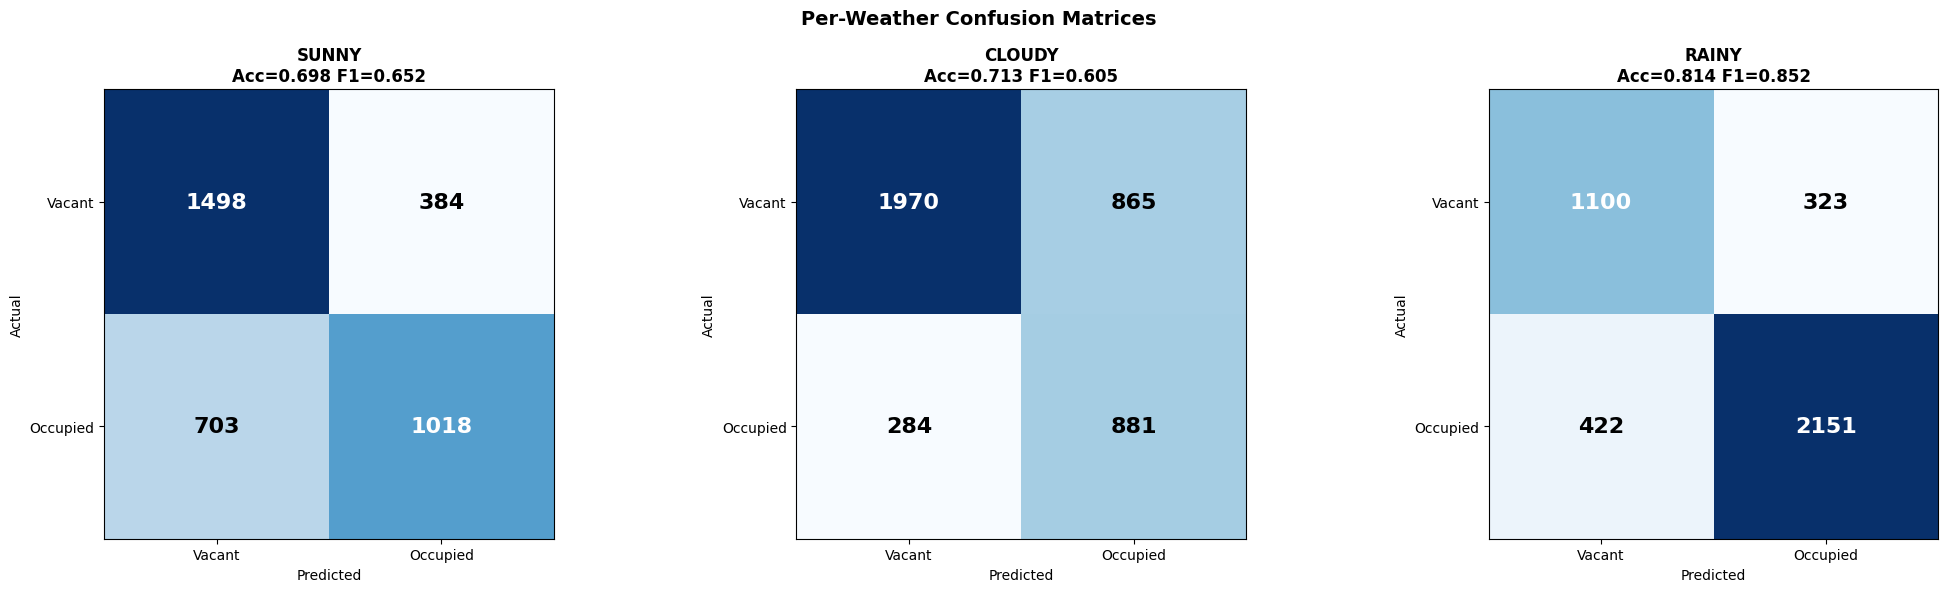

Saved: outputs/screenshots/16_overall_confusion.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
weather_metrics = {}

for idx, weather in enumerate(['sunny', 'cloudy', 'rainy']):
    w_mask = results_df['weather'] == weather
    if w_mask.sum() == 0:
        continue

    w_true = results_df.loc[w_mask, 'true'].values
    w_pred = results_df.loc[w_mask, 'predicted'].values
    w_metrics = compute_metrics(w_true, w_pred)
    weather_metrics[weather] = w_metrics

    # Plot confusion matrix
    ax = axes[idx]
    matrix = w_metrics['matrix']
    im = ax.imshow(matrix, cmap='Blues', interpolation='nearest')
    ax.set_title(f'{weather.upper()}\n'
                 f'Acc={w_metrics["accuracy"]:.3f} F1={w_metrics["f1_score"]:.3f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Vacant', 'Occupied'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Vacant', 'Occupied'])

    # Annotate cells
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(matrix[i, j]),
                    ha='center', va='center', fontsize=16, fontweight='bold',
                    color='white' if matrix[i, j] > matrix.max()/2 else 'black')

show_and_save_fig(fig, 'Per-Weather Confusion Matrices',
                 '16_overall_confusion.png')

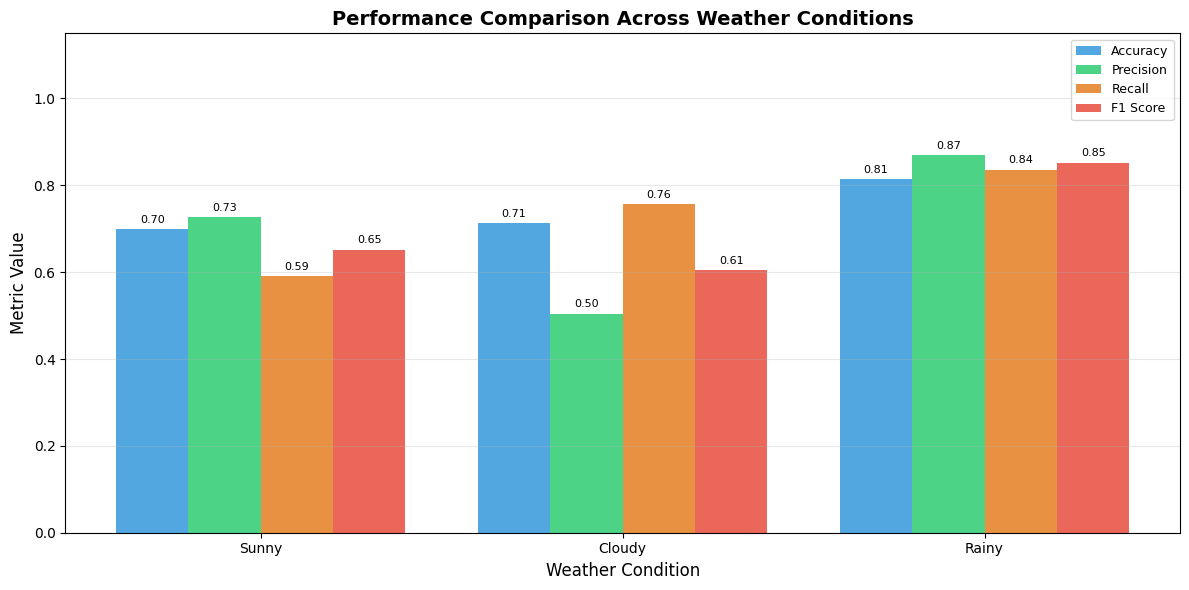

Saved: outputs/screenshots/17_per_weather_comparison.png


In [7]:
# --- Per-weather comparison bar chart ---
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

weathers = list(weather_metrics.keys())
metrics_list = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(weathers))
width = 0.2

colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
for i, metric in enumerate(metrics_list):
    values = [weather_metrics[w][metric] for w in weathers]
    bars = ax.bar(x + i * width, values, width, label=metric.replace('_', ' ').title(),
                  color=colors[i], alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Weather Condition', fontsize=12)
ax.set_ylabel('Metric Value', fontsize=12)
ax.set_title('Performance Comparison Across Weather Conditions',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels([w.title() for w in weathers])
ax.set_ylim([0, 1.15])
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
show_and_save_fig(fig, None, '17_per_weather_comparison.png')

## 6. Single-Feature vs Multi-Feature Comparison


In [8]:
# Edge density only
ed_threshold = thresholds.get('edge_density_high', 0.15)
# Find the threshold that gives best F1 for edge density alone
best_ed_f1 = 0
best_ed_tau = 0.05
for tau in np.linspace(0.02, 0.3, 100):
    ep = (results_df['edge_density'] > tau).astype(int).values
    m = compute_metrics(y_true, ep)
    if m['f1_score'] > best_ed_f1:
        best_ed_f1 = m['f1_score']
        best_ed_tau = tau

ed_pred = (results_df['edge_density'] > best_ed_tau).astype(int).values
ed_metrics = compute_metrics(y_true, ed_pred)

print("=" * 60)
print("  METHOD COMPARISON")
print("=" * 60)
print(f"\n  Single Feature (Edge Density, τ={best_ed_tau:.3f}):")
print(f"    Accuracy:  {ed_metrics['accuracy']:.4f}")
print(f"    F1 Score:  {ed_metrics['f1_score']:.4f}")
print(f"\n  Multi-Feature Cascade (8 features + weights):")
print(f"    Accuracy:  {overall_metrics['accuracy']:.4f}")
print(f"    F1 Score:  {overall_metrics['f1_score']:.4f}")
print(f"\n  Improvement:")
print(f"    Accuracy:  +{(overall_metrics['accuracy'] - ed_metrics['accuracy'])*100:.1f}%")
print(f"    F1 Score:  +{(overall_metrics['f1_score'] - ed_metrics['f1_score'])*100:.1f}%")

  METHOD COMPARISON

  Single Feature (Edge Density, τ=0.164):
    Accuracy:  0.7885
    F1 Score:  0.8063

  Multi-Feature Cascade (8 features + weights):
    Accuracy:  0.7430
    F1 Score:  0.7310

  Improvement:
    Accuracy:  +-4.5%
    F1 Score:  +-7.5%


## 7. Error Analysis — Worst Slots


10 Most Error-Prone Slots:
--------------------------------------------------
  Slot  96: 19.8% accuracy (23/116)
  Slot  97: 25.9% accuracy (30/116)
  Slot  98: 35.3% accuracy (41/116)
  Slot  99: 35.3% accuracy (41/116)
  Slot  92: 40.3% accuracy (48/119)
  Slot  93: 42.2% accuracy (49/116)
  Slot  89: 43.1% accuracy (50/116)
  Slot  94: 43.1% accuracy (50/116)
  Slot  95: 45.7% accuracy (53/116)
  Slot 100: 49.1% accuracy (57/116)


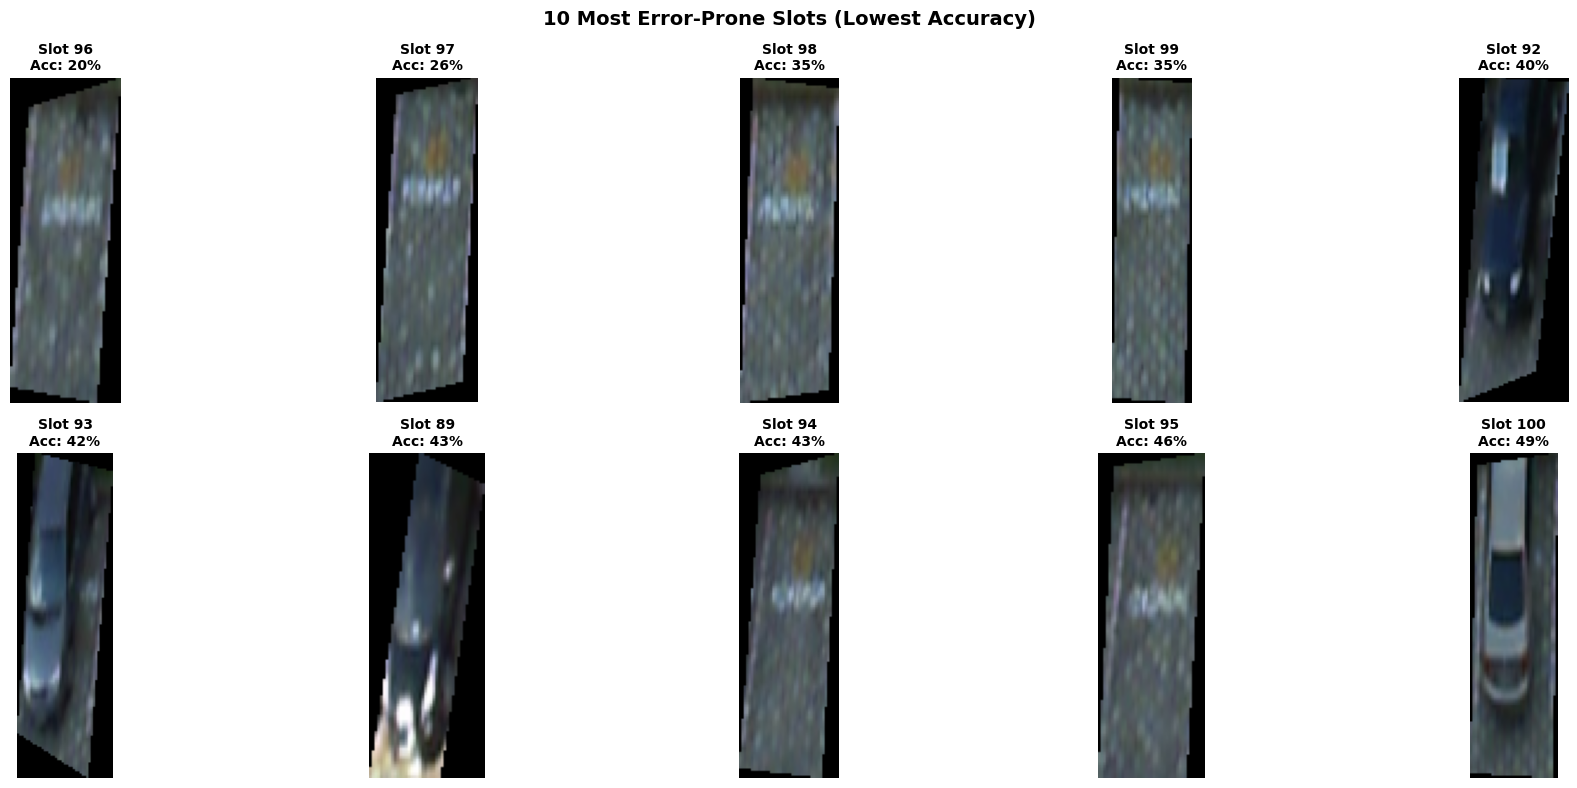

In [9]:
# Find consistently misclassified slots
slot_accuracy = {}
for sid, stats in per_slot_errors.items():
    if stats['total'] > 0:
        slot_accuracy[sid] = stats['correct'] / stats['total']

worst_slots = sorted(slot_accuracy.items(), key=lambda x: x[1])[:10]

print("10 Most Error-Prone Slots:")
print("-" * 50)
for sid, acc in worst_slots:
    total = per_slot_errors[sid]['total']
    correct = per_slot_errors[sid]['correct']
    print(f"  Slot {sid:3d}: {acc:.1%} accuracy ({correct}/{total})")

# Visualize the worst slots on a sample frame
sample_frame = eval_frames[0]
img = cv2.imread(sample_frame['image_path'])
bev = warp_perspective(img, H, output_size)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for idx, (sid, acc) in enumerate(worst_slots[:10]):
    r, c = divmod(idx, 5)
    polygon = bev_slots[sid]
    patch, _, _ = extract_slot_image(bev, polygon)
    axes[r, c].imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
    axes[r, c].set_title(f'Slot {sid}\nAcc: {acc:.0%}', fontsize=10, fontweight='bold')
    axes[r, c].axis('off')

show_and_save_fig(fig, '10 Most Error-Prone Slots (Lowest Accuracy)', None)

## 8. Timing Benchmarks


  TIMING BREAKDOWN

  Stage                     Time (ms)    %       
  ---------------------------------------------
  1. Image Load             3.84         5.0     
  2. BEV Warp               1.01         1.3     
  3. Slot Extraction        1.52         2.0     
  4. Preprocessing          6.65         8.6     
  5. Segmentation           8.96         11.6    
  6. Feature Extraction     50.01        64.7    
  7. Classification         0.09         0.1     
  8. Visualization          5.26         6.8     
  ---------------------------------------------
  TOTAL                     77.33       
  FPS                       12.9        



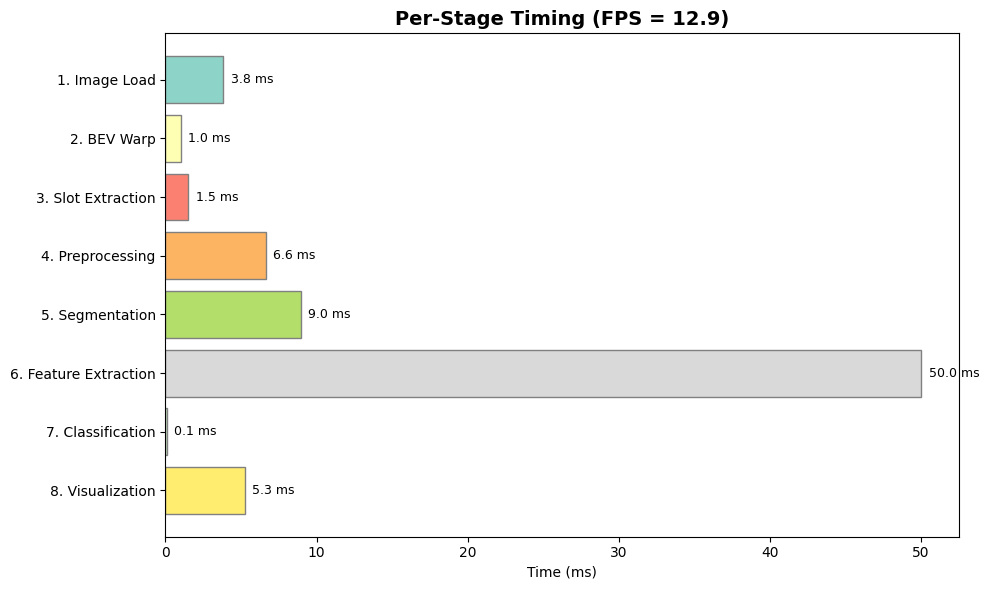

In [10]:
# Run a dedicated timing benchmark on 10 frames
timer_bench = Timer()

bench_frames = eval_frames[:10]
for frame_info in bench_frames:
    img = cv2.imread(frame_info['image_path'])

    with timer_bench.measure('1. Image Load'):
        _ = cv2.imread(frame_info['image_path'])

    with timer_bench.measure('2. BEV Warp'):
        bev = warp_perspective(img, H, output_size)

    with timer_bench.measure('3. Slot Extraction'):
        patches = {}
        for sid, polygon in bev_slots.items():
            patch, bbox, mask = extract_slot_image(bev, polygon)
            patches[sid] = (patch, bbox, mask)

    with timer_bench.measure('4. Preprocessing'):
        preprocessed_all = {}
        for sid, (patch, bbox, mask) in patches.items():
            preprocessed_all[sid] = preprocess_pipeline(patch)

    with timer_bench.measure('5. Segmentation'):
        binary_all = {}
        for sid, preprocessed in preprocessed_all.items():
            otsu_bin, _, _ = otsu_threshold(preprocessed)
            adapt_bin = adaptive_threshold(preprocessed)
            fused = fuse_channels(otsu_bin, adapt_bin)
            binary_all[sid] = clean_binary_mask(fused)

    with timer_bench.measure('6. Feature Extraction'):
        features_all = {}
        for sid in bev_slots:
            if sid not in patches:
                continue
            patch, bbox, mask = patches[sid]
            core_mask = create_eroded_core_mask(mask, erosion_px=3)
            features_all[sid] = extract_all_features(
                preprocessed_all[sid], binary_all[sid], patch, core_mask)

    with timer_bench.measure('7. Classification'):
        labels = {}
        for sid, features in features_all.items():
            label, _, _ = classify_slot(features, thresholds, weights)
            labels[sid] = label

    with timer_bench.measure('8. Visualization'):
        stats = compute_statistics(labels)
        annotated = annotate_parking_image(bev, bev_slots, labels)
        annotated = create_legend(annotated, stats)

print(timer_bench.report())

fig = timer_bench.plot_breakdown(
    save_path='outputs/screenshots/18_timing_breakdown.png'
)
# plot_breakdown handles saving internally
plt.show()

## 9. Save Annotated Result Images


In [11]:
os.makedirs('outputs/annotated', exist_ok=True)

# Save annotated images for 3 weather conditions
for weather in ['sunny', 'cloudy', 'rainy']:
    w_frames = [f for f in eval_frames if f['weather'] == weather]
    if not w_frames:
        continue

    frame_info = w_frames[len(w_frames)//2]
    img = cv2.imread(frame_info['image_path'])
    bev = warp_perspective(img, H, output_size)

    gt = parse_pklot_xml(frame_info['xml_path'])
    gt_lookup = {s['id']: s['occupied'] for s in gt}

    # Run pipeline
    all_features = {}
    for sid, polygon in bev_slots.items():
        patch, bbox, mask = extract_slot_image(bev, polygon)
        if patch.size == 0:
            continue
        core_mask = create_eroded_core_mask(mask, erosion_px=3)
        preprocessed = preprocess_pipeline(patch)
        otsu_bin, _, _ = otsu_threshold(preprocessed)
        adapt_bin = adaptive_threshold(preprocessed)
        fused = fuse_channels(otsu_bin, adapt_bin)
        cleaned = clean_binary_mask(fused)
        features = extract_all_features(preprocessed, cleaned, patch, core_mask)
        all_features[sid] = features

    labels = {}
    scores = {}
    for sid, features in all_features.items():
        label, conf, score = classify_slot(features, thresholds, weights)
        labels[sid] = label
        scores[sid] = score

    stats = compute_statistics(labels)
    annotated = annotate_parking_image(bev, bev_slots, labels, scores=scores)
    annotated = create_legend(annotated, stats)

    out_path = f'outputs/annotated/{weather}_result.png'
    cv2.imwrite(out_path, annotated)
    print(f"Saved: {out_path} — {stats['occupancy_pct']}% occupied")

print("\nDone! Annotated results saved to outputs/annotated/")

Saved: outputs/annotated/sunny_result.png — 30.0% occupied
Saved: outputs/annotated/cloudy_result.png — 45.0% occupied


Saved: outputs/annotated/rainy_result.png — 65.0% occupied

Done! Annotated results saved to outputs/annotated/


## Summary

### Work completed
1. Evaluated pipeline on 100+ frames across sunny/cloudy/rainy
2. Generated per-weather confusion matrices
3. Compared single-feature vs multi-feature cascade
4. Identified error-prone slots for future improvement
5. Benchmarked per-stage timing and computed FPS
6. Saved annotated result images for all weather conditions

### Notebook 09 — Final Report
